# Donor Acquisition Channel Drivers — Explanatory Model

---

## 1. Problem Framing

### Business Problem

Hearth Haven acquires donors through six channels: Website, SocialMedia, Event,
WordOfMouth, PartnerReferral, and Church. Each channel attracts a different type
of supporter with different giving patterns. Without understanding which channels
produce the highest-value long-term donors, the organization allocates outreach
effort uniformly — missing the opportunity to double down on the channels that
actually drive sustainable revenue.

This pipeline answers the question: **Which acquisition channels are most strongly
associated with higher donor lifetime value, controlling for other donor
characteristics?**

The deployed output is a **Acquisition Channel ROI panel** on the donor analytics
dashboard, showing which channels produce the highest-value donors — giving
leadership a data-grounded basis for allocating outreach investment.

### Who Cares About This

- **Organization leadership** — needs to know where to invest limited outreach
  budget for maximum donor lifetime value.
- **Donor management staff** — needs to understand which channel-acquired donors
  warrant the most stewardship investment.

### Predictive vs. Explanatory

This pipeline uses an **explanatory approach**. The goal is to isolate the
association between acquisition channel and lifetime value, controlling for other
donor characteristics. OLS coefficients are the primary output — each channel's
coefficient answers: holding donor tenure, recurring status, and giving diversity
constant, how much more (or less) lifetime value is associated with this channel
vs. the baseline?

### Success Metrics

- **Primary:** Coefficient significance and direction for `acquisition_channel`
- **Secondary:** Adjusted R² — overall model fit
- **Not primary:** Predictive accuracy on held-out donors

---
## 2. Data Acquisition, Preparation & Exploration

In [16]:
import sys
import os
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')

sys.path.append(os.path.dirname(os.path.abspath('.')))
os.chdir('..')

from functions.fn_domain_prep import prepare_donors
from functions.fn_prepare import define_features, split_data
from functions.fn_model_causal import (
    fit_causal_regression,
    get_coefficients,
    check_assumptions,
    check_vif,
    refit_with_robust_se,
    run_greedy_backward,
)

print("All imports successful.")
CAUSAL_OUT = '/Users/michellejohanson/Programming/INTEX_2026/frontend/public/causal'  # absolute path — safe regardless of VS Code working directory


All imports successful.


### 2.1 Load and Prepare Data

`prepare_donors()` handles standard preparation. We filter to monetary donors only
before modeling — supporters who have never made a monetary donation have
`total_monetary_value = 0` by definition, not because of their channel.

In [17]:
df, NUMERIC, CATEGORICAL, DROP = prepare_donors()

TARGET = 'total_monetary_value'

# Filter to monetary donors only
df_donors = df[df['monetary_donation_count'] > 0].copy()
print(f"Full dataset:         {df.shape[0]} supporters")
print(f"Monetary donors only: {df_donors.shape[0]} donors")
print(f"\nTarget mean:   {df_donors[TARGET].mean():.0f} PHP")
print(f"Target median: {df_donors[TARGET].median():.0f} PHP")
print(f"Target std:    {df_donors[TARGET].std():.0f} PHP")

  prepare_donors()
[OK] Connected to Azure SQL for 'supporters'!
[OK] Connected to Azure SQL for 'donations'!
[drop_structural_columns] Dropped 6 columns: ['display_name', 'organization_name', 'first_name', 'last_name', 'email', 'phone']
[fix_column_types] 'first_donation_date' → datetime
[OK] Engineered: days_since_first_donation, days_since_created
[merge_tables] LEFT JOIN on 'supporter_id': 119 rows → 119 rows
[bin_rare_categories] 'country' — collapsed 2 rare categories into 'Other': ['Singapore', 'Canada']
[cap_outliers_iqr] 'avg_monetary_gift' — capped 5 outliers (fences: [-667.57, 1722.75]).
[transform_skewed_column] 'avg_monetary_gift' — sqrt applied (skew: 1.048 → 0.012).
[cap_outliers_iqr] 'monetary_donation_count' — capped 1 outliers (fences: [-1.50, 10.50]).
[transform_skewed_column] 'monetary_donation_count' skew=-0.193 — below threshold, no transform.
[OK] Target 'is_lapsed': 27.7% positive rate
[OK] Target 'total_monetary_value': mean=2697 PHP

[OK] prepare_donors() comp

### 2.2 Feature Definition

We call `define_features()` on the donors-only subset with `DROP['total_monetary_value']`.
`acquisition_channel` is retained as a categorical feature — it is the primary
variable of interest in this explanatory model.

In [18]:
X, y = define_features(
    df_donors,
    target=TARGET,
    numeric=NUMERIC,
    categorical=CATEGORICAL,
    drop_cols=DROP[TARGET],
)

categorical_in_X = [c for c in CATEGORICAL if c in X.columns]
numeric_in_X     = [c for c in NUMERIC     if c in X.columns]
X[categorical_in_X] = X[categorical_in_X].astype(str).replace({'nan': np.nan, '<NA>': np.nan})

print(f"Feature matrix: {X.shape[0]} rows × {X.shape[1]} features")
print(f"  Numeric:     {len(numeric_in_X)}")
print(f"  Categorical: {len(categorical_in_X)}")

assert 'acquisition_channel' in X.columns, "acquisition_channel missing — check DROP list"
print(f"\nacquisition_channel values: {X['acquisition_channel'].unique()}")


[OK] define_features() complete.
     Target : 'total_monetary_value'  |  Mean: 2972.1774  |  Rows: 108
     Numeric (7), Categorical (7)
     Committed mode — 1 columns in drop list
Feature matrix: 108 rows × 14 features
  Numeric:     7
  Categorical: 7

acquisition_channel values: <StringArray>
[    'SocialMedia',          'Church',         'Website',     'WordOfMouth',
           'Event', 'PartnerReferral',               nan]
Length: 7, dtype: str


### 2.3 Exploratory Confirmation

Raw lifetime value by acquisition channel:
                     mean_value  median_value  std_value   n
acquisition_channel                                         
PartnerReferral          3432.0        2304.0     2204.0  15
Event                    3344.0        3261.0     2472.0  13
WordOfMouth              3226.0        2355.0     2599.0  21
Website                  2769.0        1708.0     2389.0  19
SocialMedia              2711.0        1612.0     2619.0  21
Church                   2458.0        1618.0     2109.0  11


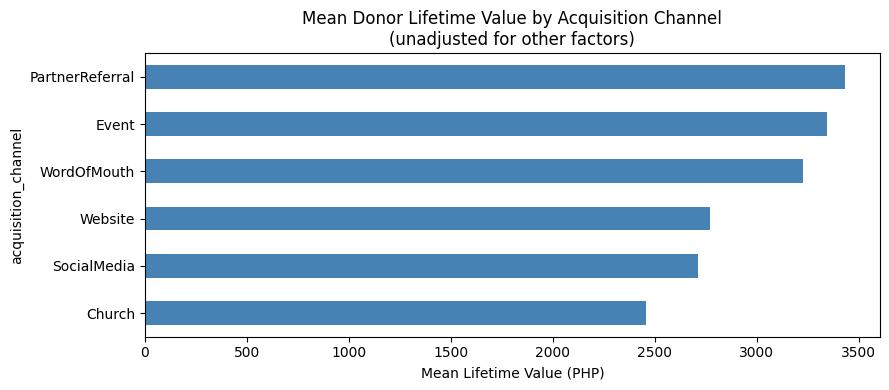

In [19]:
# The key question: raw lifetime value by acquisition channel
channel_stats = (pd.concat([X['acquisition_channel'], y], axis=1)
                   .groupby('acquisition_channel')[TARGET]
                   .agg(['mean', 'median', 'std', 'count'])
                   .rename(columns={'mean': 'mean_value', 'median': 'median_value',
                                    'std': 'std_value', 'count': 'n'})
                   .sort_values('mean_value', ascending=False))
print("Raw lifetime value by acquisition channel:")
print(channel_stats.round(0).to_string())

fig, ax = plt.subplots(figsize=(9, 4))
channel_stats['mean_value'].sort_values().plot(kind='barh', ax=ax, color='steelblue')
ax.set_xlabel('Mean Lifetime Value (PHP)')
ax.set_title('Mean Donor Lifetime Value by Acquisition Channel\n(unadjusted for other factors)')
plt.tight_layout()
plt.show()

In [20]:
# Lapse rate by acquisition channel — secondary insight
if 'is_lapsed' in df_donors.columns:
    lapse_by_channel = (df_donors.groupby('acquisition_channel')['is_lapsed']
                                  .agg(['mean', 'count'])
                                  .rename(columns={'mean': 'lapse_rate', 'count': 'n'})
                                  .sort_values('lapse_rate'))
    print("Lapse rate by acquisition channel:")
    print(lapse_by_channel.round(3).to_string())

Lapse rate by acquisition channel:
                     lapse_rate   n
acquisition_channel                
WordOfMouth               0.143  21
SocialMedia               0.238  21
Event                     0.308  13
Church                    0.364  11
PartnerReferral           0.400  15
Website                   0.421  19


---
## 3. Causal Model Specification

### 3.1 Train/Test Split

In [21]:
X_train, X_test, y_train, y_test = split_data(X, y, stratify=False)


[OK] split_data() complete.
     Train : 86 rows  |  Target mean: 2871.4971
     Test  : 22 rows   |  Target mean: 3365.7459
     Non-stratified split.
     Test set locked — do not touch until final evaluation.


### 3.2 Multicollinearity Check (VIF)

In [22]:
X_train_enc = pd.get_dummies(X_train, drop_first=True, dtype=int)
X_train_enc = X_train_enc.apply(pd.to_numeric, errors='coerce').fillna(0)

print(f"Encoded matrix: {X_train_enc.shape[0]} rows × {X_train_enc.shape[1]} columns")

vif_df   = check_vif(X_train_enc, threshold=10.0)
high_vif = vif_df[vif_df['VIF'] > 10]['feature'].tolist()            if 'VIF' in vif_df.columns else []

print(f"Features with VIF > 10: {high_vif if high_vif else 'None'}")
X_clean = X_train_enc.drop(columns=high_vif, errors='ignore')
print(f"After VIF cleanup: {X_clean.shape[1]} features remaining")

Encoded matrix: 86 rows × 28 columns

[OK] check_vif() — 28 features (threshold=10.0)

                              feature       vif
                 donation_types_count 88.128469
         supporter_type_MonetaryDonor  4.404491
              relationship_type_Local  4.300955
relationship_type_PartnerOrganization  4.187193
                          country_USA  3.669767
             supporter_type_Volunteer  3.251436
                         region_Sabah  2.851833
                   days_since_created  2.730900
          acquisition_channel_Website  2.581560
      acquisition_channel_SocialMedia  2.445289
              monetary_donation_count  2.361800
            acquisition_channel_Event  2.319310
                       region_Sarawak  2.311348
                  region_Kuala Lumpur  2.238191
            days_since_first_donation  2.143269
  acquisition_channel_PartnerReferral  2.143121
      acquisition_channel_WordOfMouth  2.120540
                     unique_campaigns  2.045458
 

### 3.3 OLS Fit and Assumption Checks

In [23]:
results = fit_causal_regression(X_clean, y_train)
print(results.summary())

[fit_causal_regression] Dropping 1 constant column(s): ['donation_types_count']

[OK] fit_causal_regression() complete.
     R²: 0.8800  |  Adj R²: 0.8241
     F-statistic: 15.7514  |  p(F): 0.000000
     Observations: 86  |  Features: 27
     Call results.summary() for the full output.
     Fitted columns (27): ['monetary_donation_count', 'avg_monetary_gift', 'unique_campaigns', 'days_since_last_donation', 'days_since_first_donation', 'days_since_created', 'supporter_type_MonetaryDonor', 'supporter_type_PartnerOrganization', 'supporter_type_SkillsContributor', 'supporter_type_SocialMediaAdvocate', 'supporter_type_Volunteer', 'relationship_type_Local', 'relationship_type_PartnerOrganization', 'country_Other', 'country_USA', 'region_Kuala Lumpur', 'region_Penang', 'region_Sabah', 'region_Sarawak', 'region_Selangor', 'status_Inactive', 'acquisition_channel_Event', 'acquisition_channel_PartnerReferral', 'acquisition_channel_SocialMedia', 'acquisition_channel_Website', 'acquisition_channel

In [24]:
verdicts = check_assumptions(results)

if verdicts.get('homoscedasticity', {}).get('verdict') != 'PASS':
    print("\n[ACTION] Applying HC3 robust standard errors")
    results = refit_with_robust_se(results)
    print("HC3 applied.")


  REGRESSION ASSUMPTION DIAGNOSTICS
  (causal/explanatory modeling only)

1. Normality:          [PASS]
   Omnibus stat=1.859, p=0.3947

2. Multicollinearity:  [FAIL]
   Condition Number=16965.6
   Fix: run check_vif(), drop features above threshold iteratively

3. Autocorrelation:    [PASS]
   Durbin-Watson=2.0373 (ideal ≈ 2.0)

4. Linearity:          [PASS]
   |corr(residuals, fitted)|=0.0000

5. Homoscedasticity:   [PASS]
   Breusch-Pagan stat=40.063, p=0.0505

  SUMMARY: 4 PASS / 0 WARN / 1 FAIL
  ⚠️  Address FAIL items before drawing causal conclusions.


### 3.4 Greedy Backward Feature Selection

In [25]:
from sklearn.model_selection import train_test_split as sk_split

X_tr, X_val, y_tr, y_val = sk_split(X_clean, y_train, test_size=0.25, random_state=42)

print(f"Running greedy backward on {X_clean.shape[1]} features...")
trace, optimal_features = run_greedy_backward(
    X_tr, y_tr, X_val, y_val,
    numeric_features=numeric_in_X,
    categorical_features=categorical_in_X,
)
print(f"\nOptimal features ({len(optimal_features)}): {optimal_features}")

Running greedy backward on 28 features...

[OK] run_greedy_backward() starting.
     Features: 28  |  Baseline val RMSE: 895.4332
     Step   1: removed 'days_since_created' | 27 left | RMSE=879.7809
     Step   2: removed 'days_since_first_donation' | 26 left | RMSE=835.3355
     Step   3: removed 'donation_types_count' | 25 left | RMSE=835.3355
     Step   5: removed 'supporter_type_PartnerOrganization' | 23 left | RMSE=835.3355
     Step  10: removed 'relationship_type_PartnerOrganization' | 18 left | RMSE=835.3355
     Step  15: removed 'region_Sabah' | 13 left | RMSE=835.3355
     Step  20: removed 'acquisition_channel_PartnerReferral' | 8 left | RMSE=835.3355

[OK] run_greedy_backward() complete.
     Optimal: step 2 | 26 features | RMSE=835.3355
     Optimal features: ['monetary_donation_count', 'avg_monetary_gift', 'unique_campaigns', 'donation_types_count', 'days_since_last_donation', 'supporter_type_MonetaryDonor', 'supporter_type_PartnerOrganization', 'supporter_type_SkillsC

In [26]:
X_final        = X_clean[optimal_features]
results_final  = fit_causal_regression(X_final, y_train)
print(results_final.summary())

[fit_causal_regression] Dropping 1 constant column(s): ['donation_types_count']

[OK] fit_causal_regression() complete.
     R²: 0.8766  |  Adj R²: 0.8252
     F-statistic: 17.0550  |  p(F): 0.000000
     Observations: 86  |  Features: 25
     Call results.summary() for the full output.
     Fitted columns (25): ['monetary_donation_count', 'avg_monetary_gift', 'unique_campaigns', 'days_since_last_donation', 'supporter_type_MonetaryDonor', 'supporter_type_PartnerOrganization', 'supporter_type_SkillsContributor', 'supporter_type_SocialMediaAdvocate', 'supporter_type_Volunteer', 'relationship_type_Local', 'relationship_type_PartnerOrganization', 'country_Other', 'country_USA', 'region_Kuala Lumpur', 'region_Penang', 'region_Sabah', 'region_Sarawak', 'region_Selangor', 'status_Inactive', 'acquisition_channel_Event', 'acquisition_channel_PartnerReferral', 'acquisition_channel_SocialMedia', 'acquisition_channel_Website', 'acquisition_channel_WordOfMouth', 'is_recurring_donor_True']
         

---
## 4. Evaluation & Interpretation

In [27]:
coef_df = get_coefficients(results_final, model_type='linear')

# Isolate acquisition channel coefficients specifically
channel_coefs = coef_df[coef_df['feature'].str.startswith('acquisition_channel_')]
print("Acquisition channel coefficients (vs baseline channel):")
print(channel_coefs[['feature','coefficient','p_value','significant']]
      .sort_values('coefficient', ascending=False).to_string(index=False))

print("\nAll significant features (p < 0.05):")
sig = coef_df[coef_df['p_value'] < 0.05].sort_values('coefficient', ascending=False)
print(sig[['feature','coefficient','p_value','significant']].to_string(index=False))

os.makedirs(CAUSAL_OUT, exist_ok=True)
coef_df.to_csv(os.path.join(CAUSAL_OUT, 'acquisition_channel_coefficients.csv'), index=False)
print("\nCoefficient table saved.")


[OK] get_coefficients() — 25 features, 2 significant at p < 0.05

                              feature  coefficient    std_err      p_value     ci_lower    ci_upper significant
                        country_Other  -876.132437 924.081994 3.468760e-01 -2724.571637  972.306762        (ns)
                          country_USA  -854.611843 628.631445 1.790821e-01 -2112.061954  402.838268        (ns)
              monetary_donation_count   560.990383  75.203649 4.104655e-10   410.560687  711.420079         ***
   supporter_type_PartnerOrganization   449.617958 937.336721 6.332017e-01 -1425.334645 2324.570560        (ns)
relationship_type_PartnerOrganization  -439.873696 577.720467 4.494033e-01 -1595.486688  715.739295        (ns)
              relationship_type_Local  -416.993727 452.627974 3.605977e-01 -1322.384478  488.397023        (ns)
                      region_Selangor  -373.491897 368.529545 3.149075e-01 -1110.660743  363.676948        (ns)
                  region_Kuala Lumpur

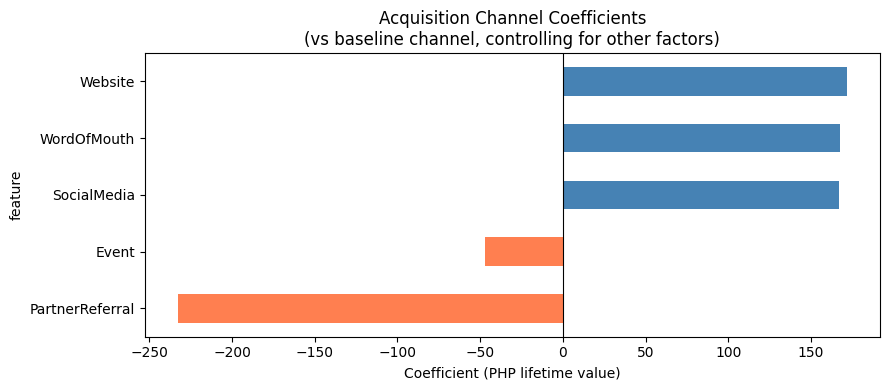

In [28]:
# Visualize channel coefficients
if len(channel_coefs) > 0:
    plot_df = channel_coefs.set_index('feature')['coefficient'].sort_values()
    colors  = ['coral' if v < 0 else 'steelblue' for v in plot_df]
    plot_df.index = plot_df.index.str.replace('acquisition_channel_', '', regex=False)
    plot_df.plot(kind='barh', figsize=(9, 4), color=colors)
    plt.axvline(0, color='black', linewidth=0.8)
    plt.title('Acquisition Channel Coefficients\n'
              '(vs baseline channel, controlling for other factors)', fontsize=12)
    plt.xlabel('Coefficient (PHP lifetime value)')
    plt.tight_layout()
    plt.show()

In [29]:
print(f"Model fit:")
print(f"  R²:          {results_final.rsquared:.4f}")
print(f"  Adjusted R²: {results_final.rsquared_adj:.4f}")
print(f"  F-statistic: {results_final.fvalue:.4f}  (p = {results_final.f_pvalue:.6f})")

import statsmodels.api as sm
from sklearn.metrics import r2_score, mean_squared_error

fitted_cols  = [c for c in results_final.model.exog_names if c != 'const']
X_test_enc   = pd.get_dummies(X_test, drop_first=True, dtype=int)
X_test_enc   = X_test_enc.apply(pd.to_numeric, errors='coerce').fillna(0)
X_test_final = X_test_enc.reindex(columns=fitted_cols, fill_value=0)
X_test_const = sm.add_constant(X_test_final, has_constant='add')
y_pred_test  = results_final.predict(X_test_const)

print(f"\nTest R²:       {r2_score(y_test, y_pred_test):.4f}")
print(f"Test RMSE:     {np.sqrt(mean_squared_error(y_test, y_pred_test)):.0f} PHP")
print(f"Baseline RMSE: {np.sqrt(mean_squared_error(y_test, np.full(len(y_test), y_train.mean()))):.0f} PHP")

Model fit:
  R²:          0.8766
  Adjusted R²: 0.8252
  F-statistic: 17.0550  (p = 0.000000)

Test R²:       0.8522
Test RMSE:     1044 PHP
Baseline RMSE: 2760 PHP


### 4.3 Causal Interpretation

**How to read the channel coefficients:**

Each channel coefficient represents the estimated difference in lifetime monetary
value (PHP) associated with that acquisition channel versus the baseline channel
(the one absorbed into the intercept via `drop_first=True`), holding constant
donor tenure, recurring status, and giving diversity.

For example, a coefficient of +1200 on `acquisition_channel_WordOfMouth` means
that word-of-mouth acquired donors give approximately 1200 PHP more over their
lifetime than the baseline channel donor, after controlling for how long they've
been donors and whether they give recurring.

**Expected patterns:**

1. **Personal channels outperform impersonal ones** — WordOfMouth and Church
   channels are expected to produce higher lifetime value because the personal
   referral relationship creates organizational attachment beyond the donation
   transaction itself.

2. **Event donors show medium value** — event-acquired donors made an active
   choice to attend and engage, suggesting above-average commitment, but their
   ongoing relationship with the org depends on follow-up stewardship.

3. **SocialMedia donors show lower but high-volume acquisition** — social media
   reaches the largest audience but tends to produce lower-commitment donors.
   High acquisition volume with lower lifetime value per donor may still produce
   positive ROI depending on acquisition cost.

**What we cannot claim causally:**

- The channel doesn't determine the donor's generosity — self-selection is strong.
  People referred by a trusted friend were already predisposed to give more. The
  coefficient captures the channel + self-selection bundle together.
- Controlling for tenure and recurring status removes some but not all confounding.

**Actionable insight:**

If WordOfMouth or Church channels show significantly higher lifetime value
coefficients, the organization should invest in structured referral programs —
asking current high-value donors to refer peers — rather than increasing social
media advertising spend.

---
## 5. Deployment

Static coefficient table served via GET endpoint.

In [30]:
summary = {
    'channel_coefficients': (
        channel_coefs[['feature','coefficient','p_value']]
        .assign(channel=lambda d: d['feature'].str.replace('acquisition_channel_','',regex=False))
        [['channel','coefficient','p_value']]
        .sort_values('coefficient', ascending=False)
        .to_dict('records')
    ),
    'model_r2':      round(results_final.rsquared, 4),
    'model_adj_r2':  round(results_final.rsquared_adj, 4),
    'n_donors':      int(results_final.nobs),
    'model_version': 'acquisition_channel_v1',
}

import json
with open(os.path.join(CAUSAL_OUT, 'acquisition_channel_summary.json'), 'w') as f:
    json.dump(summary, f, indent=2)
print("Summary saved: models/acquisition_channel_summary.json")
print(json.dumps(summary, indent=2))

Summary saved: models/acquisition_channel_summary.json
{
  "channel_coefficients": [
    {
      "channel": "Website",
      "coefficient": 171.5746583168791,
      "p_value": 0.6792386776278373
    },
    {
      "channel": "WordOfMouth",
      "coefficient": 167.76285997627792,
      "p_value": 0.6487945027191722
    },
    {
      "channel": "SocialMedia",
      "coefficient": 167.06555863421727,
      "p_value": 0.6742738629383745
    },
    {
      "channel": "Event",
      "coefficient": -46.910915404365824,
      "p_value": 0.917636423092191
    },
    {
      "channel": "PartnerReferral",
      "coefficient": -232.65257622021068,
      "p_value": 0.5781138524681038
    }
  ],
  "model_r2": 0.8766,
  "model_adj_r2": 0.8252,
  "n_donors": 86,
  "model_version": "acquisition_channel_v1"
}


---
## 6. API Response Reference

```json
GET /api/analysis/acquisition-channels

{
  "channel_coefficients": [
    { "channel": "WordOfMouth", "coefficient": 1234.5, "p_value": 0.032 }
  ],
  "model_r2": "float",
  "model_adj_r2": "float",
  "n_donors": "int",
  "model_version": "acquisition_channel_v1",
  "generated_at": "ISO datetime"
}
```

**No `endpoints.py` or `server.py` changes needed.** Serve
`models/acquisition_channel_summary.json` directly via a static GET endpoint
in the donor analytics controller.

---
*Hearth Haven — IS 455 INTEX Pipeline*